In [387]:
import pandas as pd
 
df = pd.read_csv('../data/Food_Delivery_Times.csv')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [388]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


In [389]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [390]:
for col in('Weather','Traffic_Level','Time_of_Day'):
    df[col] = df[col].fillna(df[col].mode()[0])
df.isnull().sum()
    


Order_ID                   0
Distance_km                0
Weather                    0
Traffic_Level              0
Time_of_Day                0
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [391]:

df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean())
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [392]:
df['Traffic_num'] = df['Traffic_Level'].map({'Low': 1, 'Medium': 2, 'High': 3})
df = df.drop('Traffic_Level', axis=1)
df.head()

,Order_ID,Distance_km,Weather,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Traffic_num
0,522,7.93,Windy,Afternoon,Scooter,12,1.0,43,1
1,738,16.42,Clear,Evening,Bike,20,2.0,84,2
2,741,9.52,Foggy,Night,Scooter,28,1.0,59,1
3,661,7.44,Rainy,Afternoon,Scooter,5,1.0,37,2
4,412,19.03,Clear,Morning,Bike,16,5.0,68,1


In [393]:
df['traffic-distance'] = df['Distance_km'] * df['Traffic_num']
df.head()

,Order_ID,Distance_km,Weather,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Traffic_num,traffic-distance
0,522,7.93,Windy,Afternoon,Scooter,12,1.0,43,1,7.93
1,738,16.42,Clear,Evening,Bike,20,2.0,84,2,32.84
2,741,9.52,Foggy,Night,Scooter,28,1.0,59,1,9.52
3,661,7.44,Rainy,Afternoon,Scooter,5,1.0,37,2,14.88
4,412,19.03,Clear,Morning,Bike,16,5.0,68,1,19.03


In [394]:
df['bad_weather'] = df['Weather'].apply(lambda x:1 if x in ['Rainy', 'Windy', 'Snowy'] else 0)

df.head()

,Order_ID,Distance_km,Weather,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Traffic_num,traffic-distance,bad_weather
0,522,7.93,Windy,Afternoon,Scooter,12,1.0,43,1,7.93,1
1,738,16.42,Clear,Evening,Bike,20,2.0,84,2,32.84,0
2,741,9.52,Foggy,Night,Scooter,28,1.0,59,1,9.52,0
3,661,7.44,Rainy,Afternoon,Scooter,5,1.0,37,2,14.88,1
4,412,19.03,Clear,Morning,Bike,16,5.0,68,1,19.03,0


In [395]:
df['exp_distance'] = df['Distance_km'] / (df['Courier_Experience_yrs'] + 1)
# New feature — distance per prep time
df['distance_per_prep'] = df['Distance_km'] / (df['Preparation_Time_min'] + 1)

In [396]:
# Manual encoding — must match app.py exactly
weather_map  = {'Clear':0, 'Foggy':1, 'Windy':2, 'Rainy':3, 'Snowy':4}
vehicle_map  = {'Bike':0, 'Car':1, 'Scooter':2}
time_map     = {'Morning':0, 'Afternoon':1, 'Evening':2, 'Night':3}

df['Weather']      = df['Weather'].map(weather_map)
df['Vehicle_Type'] = df['Vehicle_Type'].map(vehicle_map)
df['Time_of_Day']  = df['Time_of_Day'].map(time_map)

df.head()

,Order_ID,Distance_km,Weather,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Traffic_num,traffic-distance,bad_weather,exp_distance,distance_per_prep
0,522,7.93,2,1,2,12,1.0,43,1,7.93,1,3.965000,0.610000
1,738,16.42,0,2,0,20,2.0,84,2,32.84,0,5.473333,0.781905
2,741,9.52,1,3,2,28,1.0,59,1,9.52,0,4.760000,0.328276
3,661,7.44,3,1,2,5,1.0,37,2,14.88,1,3.720000,1.240000
4,412,19.03,0,0,0,16,5.0,68,1,19.03,0,3.171667,1.119412


In [397]:
X = df.drop(['Order_ID','Delivery_Time_min'], axis=1)
y = df['Delivery_Time_min']


In [398]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [399]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

# Train all 3
rf_model = RandomForestRegressor(n_estimators=500, max_depth=20, min_samples_split=5, random_state=42)
rf_model.fit(X_train, y_train)

xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

lgbm_model = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1074
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 11
[LightGBM] [Info] Start training from score 57.053750
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [400]:
rf_pred   = rf_model.predict(X_test)
xgb_pred  = xgb_model.predict(X_test)
lgbm_pred = lgbm_model.predict(X_test)

In [405]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    'Random Forest': (rf_model,   rf_pred),
    'XGBoost':       (xgb_model,  xgb_pred),
    'LightGBM':      (lgbm_model, lgbm_pred)
}

for name, (m, p) in models.items():
    print(f"{name}")
    print(f"  MAE  : {round(mean_absolute_error(y_test, p), 2)}")
    print(f"  RMSE : {round(np.sqrt(mean_squared_error(y_test, p)), 2)}")
    print(f"  R²   : {round(r2_score(y_test, p), 2)}")
    print()

Random Forest
  MAE  : 6.88
  RMSE : 9.8
  R²   : 0.79

XGBoost
  MAE  : 7.35
  RMSE : 10.21
  R²   : 0.77

LightGBM
  MAE  : 7.46
  RMSE : 10.42
  R²   : 0.76



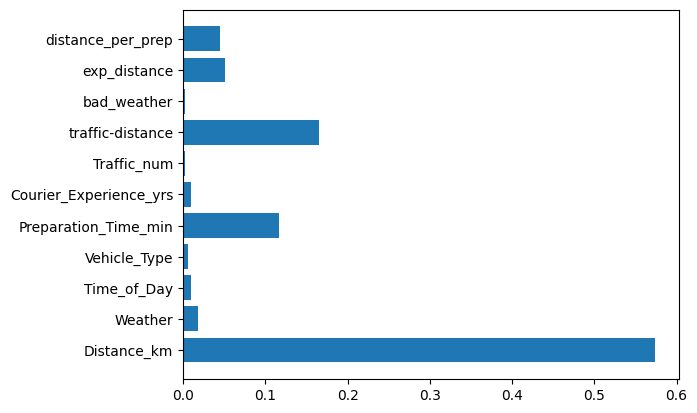

In [402]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
plt.barh(X.columns, importances)
plt.show()

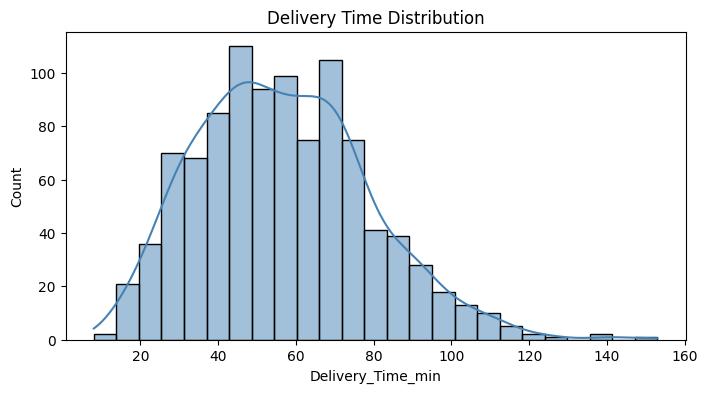

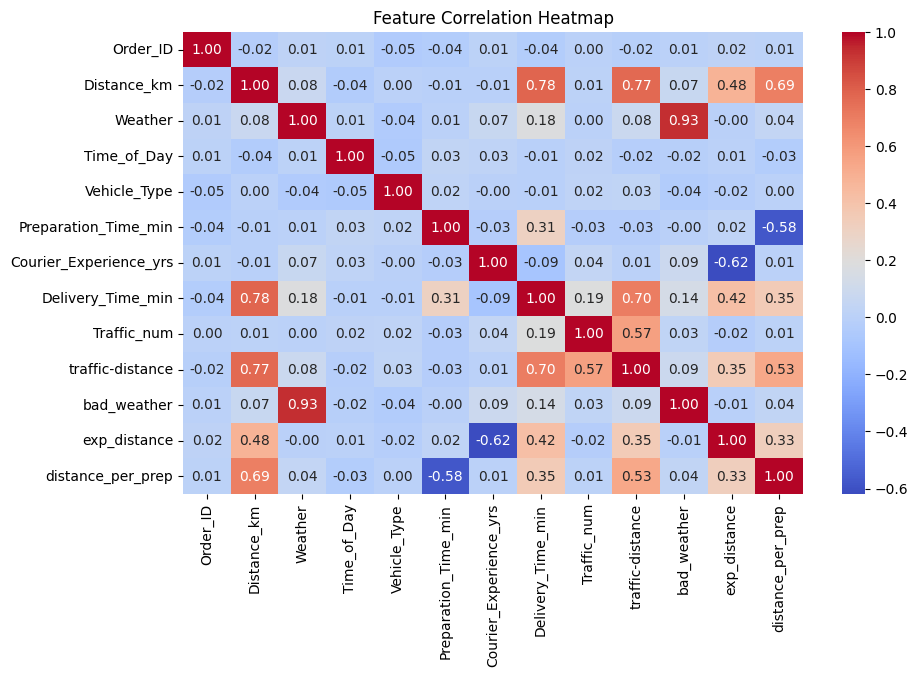

In [403]:
import seaborn as sns

# 1. Delivery Time Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Delivery_Time_min'], kde=True, color='steelblue')
plt.title("Delivery Time Distribution")
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

In [404]:
import pickle
import os

# Auto pick best model
best_name, (best_model, best_pred) = min(models.items(), key=lambda x: mean_absolute_error(y_test, x[1][1]))
print("✅ Best Model:", best_name)

pickle.dump(best_model, open('../model/model.pkl', 'wb'))
print("✅ Model saved!")

✅ Best Model: Random Forest
✅ Model saved!
